In [1]:
import hoda
import tensorly as tl
import mne
%load_ext autoreload
%autoreload 2
mne.set_log_level('ERROR')
tl.set_backend('numpy')
tl.get_backend()

'numpy'

In [2]:
from moabb.paradigms import P300,LeftRightImagery
from moabb.datasets import *
from mne.decoding import Scaler


paradigm = LeftRightImagery()
dataset = BNCI2014_004()


epochs, labels, meta = paradigm.get_data(dataset=dataset, 
                                         subjects=[1],
                                         return_epochs=True)
session = meta['session'][0]
idc = meta['session'] == session
epochs = epochs[idc]
labels = labels[idc]
meta = meta[idc]

/data/leuven/352/vsc35289/miniconda3/envs/bttda/lib/python3.12/site-packages/moabb/datasets/preprocessing.py:279: UserWarning: warnEpochs <Epochs |  120 events (all good), 3 – 7.5 s, baseline off, ~3.1 MB, data loaded,
 'left_hand': 60
 'right_hand': 60>
  warn(f"warnEpochs {epochs}")
/data/leuven/352/vsc35289/miniconda3/envs/bttda/lib/python3.12/site-packages/moabb/datasets/preprocessing.py:279: UserWarning: warnEpochs <Epochs |  120 events (all good), 3 – 7.5 s, baseline off, ~3.1 MB, data loaded,
 'left_hand': 60
 'right_hand': 60>
  warn(f"warnEpochs {epochs}")
/data/leuven/352/vsc35289/miniconda3/envs/bttda/lib/python3.12/site-packages/moabb/datasets/preprocessing.py:279: UserWarning: warnEpochs <Epochs |  160 events (all good), 3 – 7.5 s, baseline off, ~4.1 MB, data loaded,
 'left_hand': 80
 'right_hand': 80>
  warn(f"warnEpochs {epochs}")
/data/leuven/352/vsc35289/miniconda3/envs/bttda/lib/python3.12/site-packages/moabb/datasets/preprocessing.py:279: UserWarning: warnEpochs <Epo

/data/leuven/352/vsc35289/miniconda3/envs/bttda/lib/python3.12/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


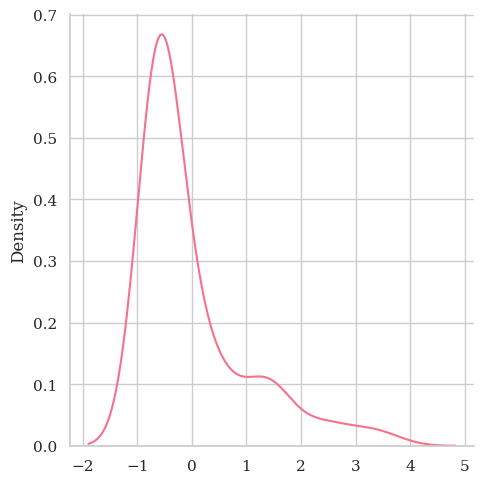

In [3]:
import tensorly.decomposition
import matplotlib.pyplot as plt
import tensorly as tl
from hoda.tensorize import stf_tensor

X = epochs.get_data()
X = stf_tensor(X, sfreq=epochs.info['sfreq'], zscore=True)
X = tl.tensor(X)
y = labels
import seaborn as sns
sns.displot(X[:,2,3,0], kind="kde")

In [4]:
tl.min(X)

-1.3322430184986822

In [7]:
from hoda.hoda import BTTDA, HODA, trunc_eigh
from hoda.cov import mode_scatter


hoda = HODA(
        rank=1,
        max_iter=1024,
        tol=1e-8,
        init ='random',
        shrinkage='lw',
        toeplitz=None,
        obj='rt',
        solver='lanczos',
        taper=True,
        extra_train_info=True,
        verbose=True,
        forward=True,
        random_state=42,
)
#%env PYTHONWARNINGS=ignore
%time hoda.fit(X,y)

Forward model :   1%|          | 9/1024 [00:00<00:18, 53.85it/s]

CPU times: user 5.12 s, sys: 186 ms, total: 5.3 s
Wall time: 670 ms


HODA(extra_train_info=True, forward=True, init='random', max_iter=1024,
     random_state=42, rank=1, taper=True, verbose=True)

/data/leuven/352/vsc35289/miniconda3/envs/bttda/lib/python3.12/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/data/leuven/352/vsc35289/miniconda3/envs/bttda/lib/python3.12/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/data/leuven/352/vsc35289/miniconda3/envs/bttda/lib/python3.12/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/data/leuven/352/vsc35289/miniconda3/envs/bttda/lib/p

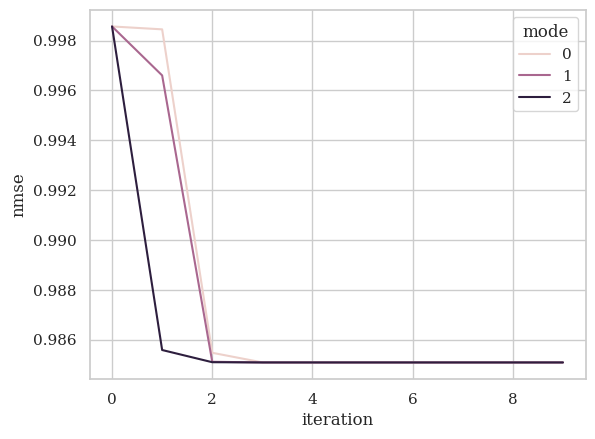

/data/leuven/352/vsc35289/miniconda3/envs/bttda/lib/python3.12/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/data/leuven/352/vsc35289/miniconda3/envs/bttda/lib/python3.12/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/data/leuven/352/vsc35289/miniconda3/envs/bttda/lib/python3.12/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/data/leuven/352/vsc35289/miniconda3/envs/bttda/lib/p

<Axes: xlabel='iteration', ylabel='update'>

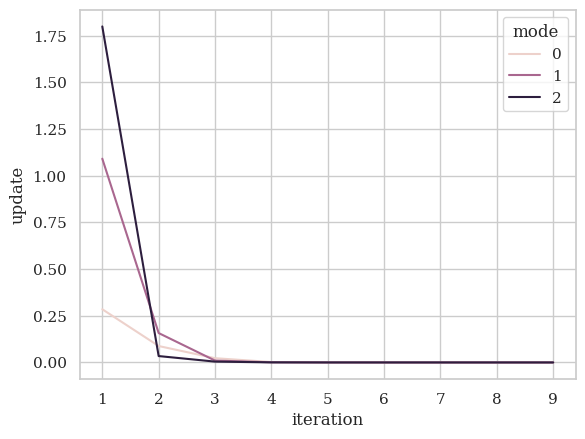

In [14]:
import pandas as pd
df = pd.DataFrame(bttda.train_info_)
sns.lineplot(data=hoda.train_info_['forward'], x='iteration', y='nmse', hue='mode')
plt.show()
sns.lineplot(data=hoda.train_info_['forward'], x='iteration', y='update', hue='mode')